In [1]:
import os
from PIL import Image
import matplotlib.pyplot as plt
from torch.utils.data import Dataset

class Dataset(Dataset):
    def __init__(self, patches_path, labels_file, transforms=None):
        self.patches_path = patches_path # root dir of dataset
        self.img_paths = [] # list of imagens paths
        self.img_labels = [] # list of imagens labels

        with open(labels_file) as file:
            crude_lines = file.readlines() # read all lines and return a list of strings

        for line in crude_lines:
            clean_line = line.split()
            self.img_paths.append(os.path.join(self.patches_path, clean_line[0]))
            self.img_labels.append(clean_line[1])
        
        self.transforms = transforms

    def __len__(self):
        return len(self.img_labels)

    def __getitem__(self, idx):
        img_path = self.img_paths[idx]
        img = Image.open(img_path)
        label = self.img_labels[idx]
        img = self.transforms(img)

        return img, label
        

Number of images: 94493
Label: 1
Image Path: ../data/CNRPark-EXT/PATCHES/SUNNY/2015-11-12/camera8/S_2015-11-12_12.26_C08_280.jpg


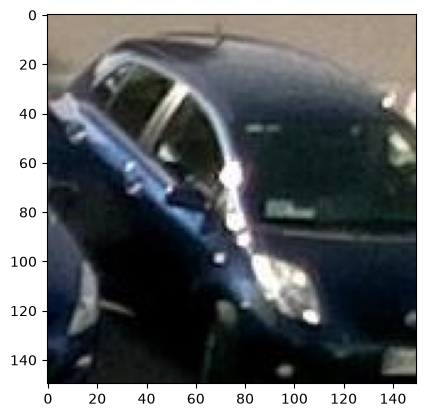

Random Image:
Label: 0
Image Path: ../data/CNRPark-EXT/PATCHES/OVERCAST/2015-12-19/camera5/O_2015-12-19_12.37_C05_274.jpg


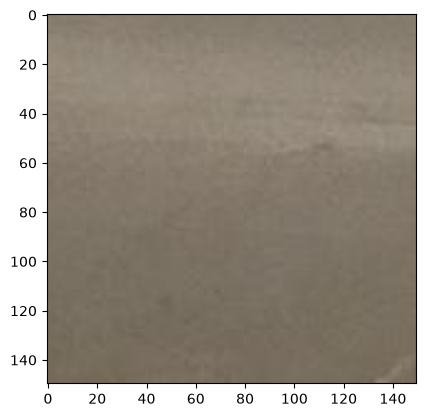

In [4]:
import random

# Testing paths and splits
dataset = Dataset(
    patches_path="../data/CNRPark-EXT/PATCHES",
    labels_file="../data/CNRPark-EXT/LABELS/train.txt",
)

print(f"Number of images: {len(dataset)}")

# Printing First Image
print(f"Label: {dataset.img_labels[0]}")
print(f"Image Path: {dataset.img_paths[0]}")
plt.imshow(Image.open(dataset.img_paths[0]))
plt.show()

# Printing Random Image
rand = random.randint(0, len(dataset) - 1)
print("Random Image:")
print(f"Label: {dataset.img_labels[rand]}")
print(f"Image Path: {dataset.img_paths[rand]}")
plt.imshow(Image.open(dataset.img_paths[rand]))
plt.show()